In [ ]:
from datasets import load_dataset
import pandas as pd

# Stream dataset
dataset = load_dataset("commaai/commaSteeringControl", split="train", streaming=True)

angles = []
for i, row in enumerate(dataset):
    if i >= 20000:  # limit for speed
        break
    angles.append(row['steeringAngleDeg'])

# Convert to DataFrame
df = pd.DataFrame({'steeringAngleDeg': angles})

# Preview
df.head()


Resolving data files:   0%|          | 0/120 [00:00<?, ?it/s]

,steeringAngleDeg
0,-1.2
1,-1.2
2,-1.2
3,-1.2
4,-1.2


In [ ]:
# Compute only the 2 main derived features
df['steering_speed'] = df['steeringAngleDeg'].diff().fillna(0)
df['steering_variation'] = df['steeringAngleDeg'].rolling(window=5).std().fillna(0)

# Optional: preview
df.head()


,steeringAngleDeg,steering_speed,steering_variation
0,-1.2,0.000000e+00,0.000000e+00
1,-1.2,0.000000e+00,0.000000e+00
2,-1.2,2.220446e-16,0.000000e+00
3,-1.2,-2.220446e-16,0.000000e+00
4,-1.2,2.220446e-16,1.570092e-16


In [ ]:
# Step: generate labels
def generate_label(row):
    if abs(row['steering_speed']) < 0.5 and row['steering_variation'] < 0.5:
        return 'normal'
    elif abs(row['steering_speed']) < 2 and row['steering_variation'] < 2:
        return 'micro_corrections_high'
    else:
        return 'sudden_jolt'

df['label'] = df.apply(generate_label, axis=1)
# --- Step 4: Prepare features and labels ---
features = ['steering_speed', 'steering_variation']  # or include 'steering_jerk' later
X = df[features]
y = df['label']


In [ ]:
# Check label distribution
df['label'].value_counts()


,count
label,
normal,19062
micro_corrections_high,757
sudden_jolt,181


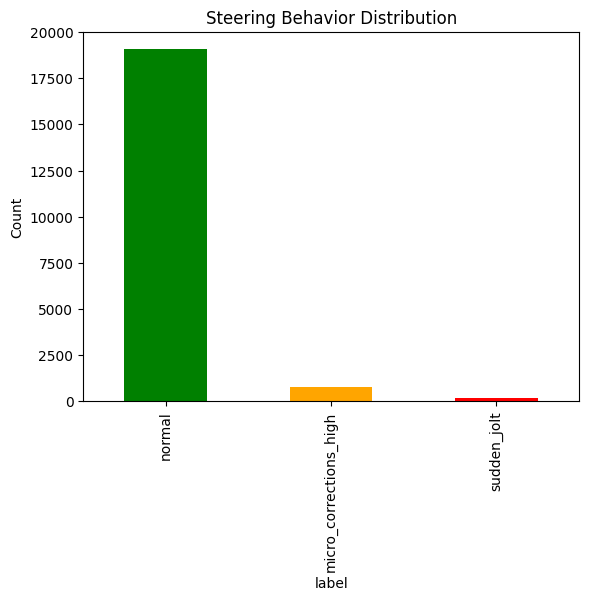

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Steering Behavior Distribution')
plt.ylabel('Count')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train tree with limited depth
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[ 130    0    0]
 [   1 3828    0]
 [   0    0   41]]

Classification Report:
                         precision    recall  f1-score   support

micro_corrections_high       0.99      1.00      1.00       130
                normal       1.00      1.00      1.00      3829
           sudden_jolt       1.00      1.00      1.00        41

              accuracy                           1.00      4000
             macro avg       1.00      1.00      1.00      4000
          weighted avg       1.00      1.00      1.00      4000



In [ ]:
# Save the labeled dataset to CSV
df.to_csv("steering_data_labeled.csv", index=False)

# Preview first few lines
df.head()


,steeringAngleDeg,steering_speed,steering_variation,label
0,-1.2,0.000000e+00,0.000000e+00,normal
1,-1.2,0.000000e+00,0.000000e+00,normal
2,-1.2,2.220446e-16,0.000000e+00,normal
3,-1.2,-2.220446e-16,0.000000e+00,normal
4,-1.2,2.220446e-16,1.570092e-16,normal
